In [1]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(project_root)
if project_root not in sys.path:
    sys.path.append(project_root)

c:\Users\Camille\Documents\TWR\deep_agents_twr


In [2]:
from deepagents import create_deep_agent, CompiledSubAgent
from langchain.agents import create_agent
from app.tools.data_tools import *
from app.tools.metrics_agent_tools import *
from app.agents.prompts.data_analist_prompt import DATA_ANALYST_PROMPT, OSINT_THREAT_ANALYST_PROMPT
from app.agents.prompts.data_engineer_prompt import DATA_ENGINEER_PROMPT
from app.agents.prompts.ml_analist_prompt import ML_ANALYST_PROMPT, CLUSTERING_SPECIALIST_PROMPT
from app.agents.prompts.orchestrator_prompt import ORCHESTRATOR_SYSTEM_PROMPT

c:\Users\Camille\Documents\TWR\deep_agents_twr\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Camille\Documents\TWR\deep_agents_twr\.venv\Lib\site-packages\motor\core.py:171: UserWarning: You appear to be connected to a DocumentDB cluster. For more information regarding feature compatibility and support please visit https://www.mongodb.com/supportability/documentdb
  delegate = self.__delegate_class__(*args, **kwargs)


Garantindo índices...
Using 11 out of 12 cores


c:\Users\Camille\Documents\TWR\deep_agents_twr\app\tools\metrics_agent_tools.py:33: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_search = TavilySearchResults(max_results=1)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 16766.80it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [3]:
from langfuse import Langfuse, get_client
from langfuse.langchain import CallbackHandler

import os

Langfuse(
    public_key=os.getenv("LANGFUSE_PUBLIC_KEY"),
    secret_key=os.getenv("LANGFUSE_SECRET_KEY"),
    host="https://cloud.langfuse.com" 
)

langfuse = get_client()
langfuse_handler = CallbackHandler()

In [4]:
data_eng_tools = [query_sql_campaigns, traffic_source_by_campaign, query_mongo_requests]
clustering_specialist_tools = [analyze_traffic_patterns]
osint_threat_analyst_tools = [tavily_tool, extract_suspicious_artifacts]

In [5]:
from langchain_openai import ChatOpenAI

llm_fast = ChatOpenAI(
      model="gpt-4.1-mini"
)

llm_reasoning = ChatOpenAI(
      model="gpt-4o"
)

In [6]:
from typing import Annotated, Literal, TypedDict
from langchain_core.messages import AIMessage, SystemMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from pydantic import BaseModel

# ==========================================
# 1. Definição do Estado Global (A "Mochila")
# ==========================================
class SecOpsState(MessagesState):
    next_agent: str 

# ==========================================
# 2. Criando os Subagentes (Nós Especialistas)
# ==========================================
data_engineer_agent = create_agent(llm_fast, tools=data_eng_tools, system_prompt=DATA_ENGINEER_PROMPT)
clustering_specialist_agent = create_agent(llm_fast, tools=clustering_specialist_tools, system_prompt=CLUSTERING_SPECIALIST_PROMPT)
osint_threat_analyst_agent = create_agent(llm_fast, tools=osint_threat_analyst_tools, system_prompt=OSINT_THREAT_ANALYST_PROMPT)

# ==========================================
# 3. Wrappers dos Nós (Assinando as mensagens)
# ==========================================
async def data_engineer_node(state: SecOpsState):
    result = await data_engineer_agent.ainvoke({"messages": state["messages"]})
    last_msg = result["messages"][-1]
    return {"messages": [AIMessage(content=last_msg.content, name="data_engineer")]}

async def clustering_specialist_node(state: SecOpsState):
    result = await clustering_specialist_agent.ainvoke({"messages": state["messages"]})
    last_msg = result["messages"][-1]
    return {"messages": [AIMessage(content=last_msg.content, name="clustering_specialist")]}

async def osint_threat_analyst_node(state: SecOpsState):
    result = await osint_threat_analyst_agent.ainvoke({"messages": state["messages"]})
    last_msg = result["messages"][-1]
    # NOME CORRIGIDO AQUI
    return {"messages": [AIMessage(content=last_msg.content, name="osint_threat_analyst")]}

# ==========================================
# 4. O Nó do Supervisor (O Orquestrador)
# ==========================================
class Router(BaseModel):
    # NOMENCLATURA PADRONIZADA AQUI
    next: Literal["data_engineer", "clustering_specialist", "osint_threat_analyst", "FINISH"]

async def supervisor_node(state: SecOpsState):
    messages = state["messages"]
    
    # 4.1 O Orquestrador decide o próximo passo usando Structured Output
    routing_chain = llm_fast.with_structured_output(Router)
    
    # PROMPT DE ROTEAMENTO BLINDADO
    routing_prompt = (
        "You are a supervisor managing a cybersecurity team: 'data_engineer', 'clustering_specialist', and 'osint_threat_analyst'.\n"
        "Look at the conversation history and route to the next agent based on this STRICT WORKFLOW:\n"
        "1. Start with 'data_engineer' to fetch the data.\n"
        "2. Next, route to 'clustering_specialist' to analyze the data.\n"
        "3. Next, route to 'osint_threat_analyst' to investigate the artifacts found.\n"
        "4. If 'osint_threat_analyst' has ALREADY provided their findings, select FINISH.\n\n"
        "DO NOT SKIP STEPS."
    )
    
    # USANDO SystemMessage NATIVO DO LANGCHAIN
    decision = await routing_chain.ainvoke([SystemMessage(content=routing_prompt)] + messages)
    
    # 4.2 Se ele decidiu FINISH, ele gera o Relatório Executivo Final e encerra
    if decision.next == "FINISH":
        # Usando o prompt mestre do Orchestrator que definimos anteriormente
        final_msg = await llm_reasoning.ainvoke([SystemMessage(content=ORCHESTRATOR_SYSTEM_PROMPT)] + messages)
        return {"messages": [AIMessage(content=final_msg.content, name="orchestrator")], "next_agent": "FINISH"}
        
    return {"next_agent": decision.next}


def supervisor_router(state: SecOpsState) -> str:
    if state["next_agent"] == "FINISH":
        return END
    return state["next_agent"]


# ==========================================
# 5. Construindo o Grafo
# ==========================================
workflow = StateGraph(SecOpsState)

# Adicionando os nós (NOMES PADRONIZADOS)
workflow.add_node("supervisor", supervisor_node)
workflow.add_node("data_engineer", data_engineer_node)
workflow.add_node("clustering_specialist", clustering_specialist_node)
workflow.add_node("osint_threat_analyst", osint_threat_analyst_node)

# O fluxo sempre começa e volta para o supervisor
workflow.add_edge(START, "supervisor")
workflow.add_edge("data_engineer", "supervisor")
workflow.add_edge("clustering_specialist", "supervisor")
workflow.add_edge("osint_threat_analyst", "supervisor")

workflow.add_conditional_edges(
    "supervisor", 
    supervisor_router,
    {
        "data_engineer": "data_engineer",
        "clustering_specialist": "clustering_specialist",
        "osint_threat_analyst": "osint_threat_analyst",
        END: END
    }
)

langgraph_agent = workflow.compile()

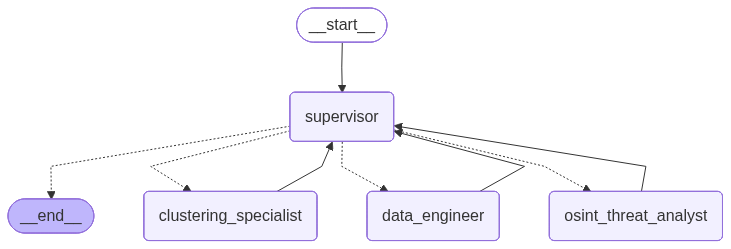

In [7]:
from IPython.display import Image, display

imagem_grafo = langgraph_agent.get_graph().draw_mermaid_png()
display(Image(imagem_grafo))
    

In [10]:
user_query = (
    "Please analyze the recent traffic from for the campaign with hash 'g1dg9qeh5m'. Identify patterns that could result in bots between human requests"
)

config = {
    "configurable": {"thread_id": "1"}, 
    "recursion_limit": 5,
     "callbacks": [langfuse_handler] 
}

response = await langgraph_agent.ainvoke(
    {"messages": [("user", user_query)]},
    config=config
)

from utils import format_messages
format_messages(response["messages"])

Start Date:  None
End date:  None
Results:  20000


GraphRecursionError: Recursion limit of 5 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/GRAPH_RECURSION_LIMIT